Le SVM cercano di trovare un iperpiano che separi i dati appartenenti a classi diverse con il margine massimo. Se i dati non sono linearmente separabili, le SVM utilizzano il **kernel trick** per trasformare i dati in uno spazio di dimensioni superiori, dove possono essere separati linearmente.

In [1]:
#Le SVM per regressione (SVR) cercano di trovare una funzione che 
# si avvicini il più possibile ai dati, mantenendo un margine di 
# tolleranza (epsilon) intorno alla funzione predetta.
# Utilizzo di SVC (Support Vector Classifier)
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Genera un dataset di classificazione con 2 feature per 
# la visualizzazione
X, y = make_classification(n_samples=100, 
                           n_features=2, 
                           n_redundant=0, 
                           n_informative=2, 
                           n_clusters_per_class=1, 
                           n_classes=2, 
                           random_state=42)

# Suddivide i dati in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crea e addestra il modello SVM con kernel lineare
svc = SVC(kernel='linear', random_state=42)
svc.fit(X_train, y_train)

# Valuta il modello
accuracy = svc.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


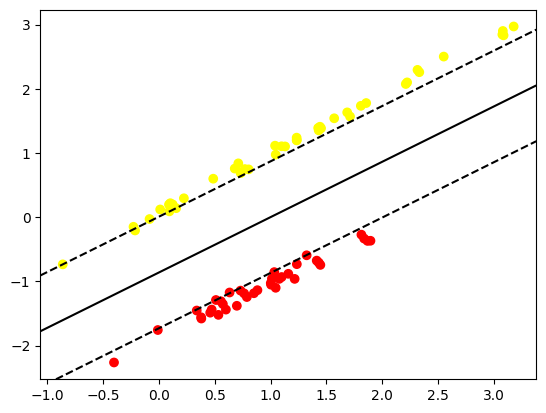

In [2]:
# Visualizzazione del Margine
import matplotlib.pyplot as plt
import numpy as np

# Visualizza i dati e il margine
def plot_svm_decision_boundary(model, X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Crea una griglia per il margine
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Disegna il margine
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='black')
    plt.show()

plot_svm_decision_boundary(svc, X_train, y_train)

In [3]:
# Utilizzo di SVR (Support Vector Regressor)
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Genera un dataset di regressione
X, y = make_regression(n_samples=100, n_features=1, noise=0.1, random_state=42)

# Suddivide i dati in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crea e addestra il modello SVR con kernel RBF
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

# Valuta il modello
score = svr.score(X_test, y_test)
print("R^2 Score:", score)

R^2 Score: 0.6302213602313782


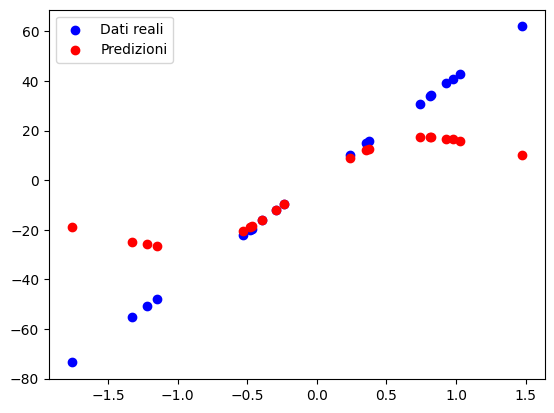

In [4]:
# Visualizza i dati e la funzione predetta
plt.scatter(X_test, y_test, color='blue', label='Dati reali')
plt.scatter(X_test, svr.predict(X_test), color='red', label='Predizioni')
plt.legend()
plt.show()

Le SVM supportano diversi tipi di kernel per trasformare i dati:
- **Lineare**: Utilizzato per dati separabili linearmente.
- **Polinomiale**: Adatto per dati con relazioni non lineari.
- **RBF (Radial Basis Function)**: Ideale per dati complessi e non lineari.
- **Sigmoid**: Utilizzato in alcune applicazioni specifiche.

In [5]:
# Esempio: Utilizzo di Kernel Polinomiale
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Genera nuovamente il dataset di classificazione per il kernel polinomiale
X_class, y_class = make_classification( n_samples=100, n_features=2, n_redundant=0, n_informative=2, 
                                        n_clusters_per_class=1, n_classes=2, random_state=42)

# Suddivide i dati di classificazione in training e test set
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Usa il kernel polinomiale con i dati di classificazione
svc_poly = SVC(kernel='poly', degree=3, random_state=42)
svc_poly.fit(X_train_class, y_train_class)
accuracy_poly = svc_poly.score(X_test_class, y_test_class)
print("Accuracy con kernel polinomiale:", accuracy_poly)

Accuracy con kernel polinomiale: 1.0
